SMART RAINWATER COLLECTION FILTRATION SYSTEM - ML TRAINING
=============================================================================
Project: Smart rainwater collection and filtration system

Author: Project Founder - Amina Baiturgan

Purpose: Train ML model to predict water quality before/after filtration

System Architecture:
- Container A (Before): Raw rainwater + sensors (TDS, Turbidity)
- Container B (After): Filtered water + sensors
- Filtration: Sieve → Magnets → DIY filter (sand/gravel/carbon/cloth)
- Rain sensor: Detects intensity (light/heavy rain)
- Raspberry Pi Pico: Collects sensor data
- ML Model: Predicts water quality based on rainfall patterns + graphs

This code prepares historical weather data for ML training.
=============================================================================

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# VISUALIZATION FUNCTIONS

In [3]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

def plot_actual_vs_predicted(y_test, y_pred, title, unit, save_name):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Scatter
    ax.scatter(y_test, y_pred, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    textstr = f'MAE: {mae:.2f} {unit}\nRMSE: {rmse:.2f} {unit}\nR²: {r2:.3f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_xlabel(f'Actual {title} ({unit})', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Predicted {title} ({unit})', fontsize=12, fontweight='bold')
    ax.set_title(f'{title} - Actual vs Predicted', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_name}")
    plt.show()

In [4]:
def plot_feature_importance(model, feature_names, title, save_name):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(feature_names)))
    ax.barh(range(len(feature_names)), 
            importances[indices], 
            color=colors[indices],
            edgecolor='black')
    
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[i] for i in indices])
    ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
    ax.set_title(f'{title} - Feature Importance', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add percentage labels
    for i, (idx, imp) in enumerate(zip(indices, importances[indices])):
        ax.text(imp + 0.01, i, f'{imp*100:.1f}%', va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_name}")
    plt.show()

In [5]:
def plot_before_after_comparison(data, save_name):
    precip_data = data[data['Rain_Intensity'] > 0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # TDS comparison
    axes[0].boxplot([precip_data['TDS_Before'], precip_data['TDS_After']],
                    tick_labels=['Before Filter', 'After Filter'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                    medianprops=dict(color='red', linewidth=2))
    axes[0].set_ylabel('TDS (mg/L)', fontsize=12, fontweight='bold')
    axes[0].set_title('TDS: Before vs After Filtration', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Turbidity comparison (tick_labels)
    axes[1].boxplot([precip_data['Turbidity_Before'], precip_data['Turbidity_After']],
                    tick_labels=['Before Filter', 'After Filter'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', edgecolor='black', linewidth=1.5),
                    medianprops=dict(color='darkred', linewidth=2))
    axes[1].set_ylabel('Turbidity (NTU)', fontsize=12, fontweight='bold')
    axes[1].set_title('Turbidity: Before vs After Filtration', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_name}")
    plt.show()

# CONFIGURATION

In [6]:
#Filter efficiency parameters(Based on DIY system)
FILTER_TDS_REDUCTION = 0.05         # 5% TDS reduction (limited)
FILTER_TURBIDITY_REDUCTION = 0.75   # 75# Turbidity reduction (excellent) 

# Water quality thresholds
SAFE_TDS_THRESHOLD = 200            # mg/L (safe for irrigation)
SAFE_TURBIDITY_THRESHOLD = 50       # NTU (acceptable for non-portable use)

# 0. DATA LOADING

In [7]:
file_path = '/Users/amina/Desktop/startups/rain drainger/ml/csv/archive.csv'
data = pd.read_csv(file_path)

print(f"\n Dataset loaded: {len(data)} rows")
print(f"Period: {data['Date'].min()} - {data['Date'].max()}")
print(f"\nFirst 5 rows:")
print(data.head())


 Dataset loaded: 104 rows
Period: 01.09.2025 - 31.10.2025

First 5 rows:
         Date  ADP_Days  Wind_Avg  T_Avg_Air
0  01.09.2025         1       4.5       27.1
1  02.09.2025         2       3.3       25.6
2  03.09.2025         3       4.4       27.6
3  04.09.2025         4       2.3       23.8
4  05.09.2025         5       3.0       23.2


# 1. DATA PREPROCESSING

In [8]:
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data['ADP_Days'] = pd.to_numeric(data['ADP_Days'], errors='coerce').fillna(0).astype(int)
data['Wind_Avg'] = pd.to_numeric(data['Wind_Avg'], errors='coerce')
data['T_Avg_Air'] = pd.to_numeric(data['T_Avg_Air'], errors='coerce')

# Remove invalid rows
data_clean = data.dropna(subset=['Date', 'Wind_Avg', 'T_Avg_Air']).copy()
data_clean = data_clean.sort_values('Date').reset_index(drop=True)

print(f"Clean dataset: {len(data_clean)} rows")

Clean dataset: 48 rows


# 2. FEATURE ENGINEERING

In [9]:
# Rain intensity classification (simulating rain sensor output)
def classify_rain_intensity(row):
    """
    Simulate Raspberry Pi Pico rain sensor classification
    
    Rain sensor detects:
    - No rain: ADP_Days > 0
    - Light rain: Wind < 4.5 m/s, T > 2°C
    - Heavy rain: Wind ≥ 5.5 m/s, T > 2°C
    - Snow: T ≤ 2°C
    
    Returns intensity code: 0 (none), 1 (light), 2 (heavy), 3 (snow)
    """
    if row['ADP_Days'] > 0:
        return 0

    temp = row['T_Avg_Air']
    wind = row['Wind_Avg']

    if temp <= 2.0:
        return 3
    elif wind >= 5.5:
        return 2
    elif wind>= 3.0:
        return 1
    else:
        return 1 

In [10]:
data_clean['Rain_Intensity'] = data_clean.apply(classify_rain_intensity, axis = 1)

In [11]:
# additional features for ML
data_clean['ADP_Days_squared'] = data_clean['ADP_Days'] ** 2
data_clean['Wind_squared'] = data_clean['Wind_Avg'] ** 2
data_clean['Temp_Wind_Interaction'] = data_clean['T_Avg_Air'] * data_clean['Wind_Avg']
data_clean['ADP_Wind_Interaction'] = data_clean['ADP_Days'] * data_clean['Wind_Avg']

# Rolling averages (temporal patterns)
data_clean['Wind_Rolling_7d'] = data_clean['Wind_Avg'].rolling(window=7, min_periods=1).mean()
data_clean['Temp_Rolling_7d'] = data_clean['T_Avg_Air'].rolling(window=7, min_periods=1).mean()

In [12]:
print(f"Created features:")
print(f"   - Rain_Intensity (0=none, 1=light, 2=heavy, 3=snow)")
print(f"   - Polynomial features (squared terms)")
print(f"   - Interaction features")
print(f"   - Rolling averages (7-day window)")

Created features:
   - Rain_Intensity (0=none, 1=light, 2=heavy, 3=snow)
   - Polynomial features (squared terms)
   - Interaction features
   - Rolling averages (7-day window)


# 3. POC. CONTAINER A (BEFORE FILTRATION) - WATER QUALITY CALCULATION

In [13]:
def calculate_tds_before(row):
    """
    Simulate TDS sensor reading in Container A (raw rainwater)
    
    Physics-based model:
    - Base TDS depends on precipitation type
    - Accumulation effect from dry days
    - First flush effect during heavy rain
    """

    intensity = row['Rain_Intensity']
    adp = row['ADP_Days']
    wind = row['Wind_Avg']

    if intensity == 0:
        return 0

    # Base TDS by presipitation type
    if intensity == 3:
        base_tds = 250.0
    elif intensity == 2:
        base_tds = 120.0
    else: # Light Rain
        base_tds = 100.0

    # Accumulation factors (dirt buildup during dry period)
    accumulation = 1.0 + (adp * 0.02)

    # First flush effect (heavy rain washes more)
    if intensity == 2:
        first_flush = 1.2
    else:
        first_flush = 1.0

    tds = base_tds * accumulation * first_flush
    return np.clip(tds, 50, 400)

In [14]:
def calculate_turbidity_before(row):
    """
    Simulate Turbidity sensor reading in Container A
    
    Turbidity = suspended particles (dirt, dust, sediment)
    """
    
    intensity = row['Rain_Intensity']
    adp = row['ADP_Days']
    wind = row['Wind_Avg']

    if intensity == 0:
        return 0

    # Base turbidity by presipication type
    if intensity == 3:
        base_turb = 4000.0 # Mud + ice + salt_slurry
    elif intensity == 2:
        base_turb = 600.0
    else:
        base_turb = 100.0

    # Accumulation and wind effect
    accumulation = 1.0 + (adp * 0.05)
    wind_effect = 1.0 + (wind * 0.02)

    turb = base_turb * accumulation * wind_effect 
    return np.clip(turb, 50, 5000)

In [15]:
data_clean['TDS_Before'] = data_clean.apply(calculate_tds_before, axis=1)
data_clean['Turbidity_Before'] = data_clean.apply(calculate_turbidity_before, axis=1)

In [16]:
print(f"Container A (Before) sensor data calculated")
print(f"\nStatistics - TDS Before:")
print(data_clean['TDS_Before'].describe())
print(f"\nStatistics - Turbidity Before:")
print(data_clean['Turbidity_Before'].describe())

Container A (Before) sensor data calculated

Statistics - TDS Before:
count     48.000000
mean      36.333333
std       75.423720
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      250.000000
Name: TDS_Before, dtype: float64

Statistics - Turbidity Before:
count      48.000000
mean      390.562500
std      1213.517911
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      4472.000000
Name: Turbidity_Before, dtype: float64


# 4. POC. CONTAINER B (AFTER FILTRATION) - FILTERED WATER QUALITY

In [17]:
# DIY system:
# 1. Sieve (removes large debris)
# 2. Neodymium magnets (captures magnetic metal particles)
# 3. Filter (multy-stage)

In [18]:
# Filter efficiency 
data_clean['TDS_After'] = data_clean['TDS_Before'] * (1 - FILTER_TDS_REDUCTION)
data_clean['Turbidity_After'] = data_clean['Turbidity_Before'] * (1 - FILTER_TURBIDITY_REDUCTION)

In [19]:
print(f"Container B (After) sensor data calculated")
print(f"\nFilter Efficiency:")
print(f"   TDS reduction: {FILTER_TDS_REDUCTION*100:.0f}%")
print(f"   Turbidity reduction: {FILTER_TURBIDITY_REDUCTION*100:.0f}%")

Container B (After) sensor data calculated

Filter Efficiency:
   TDS reduction: 5%
   Turbidity reduction: 75%


In [20]:
print(f"\nStatistics - TDS After:")
print(data_clean['TDS_After'].describe())
print(f"\nStatistics - Turbidity After:")
print(data_clean['Turbidity_After'].describe())


Statistics - TDS After:
count     48.000000
mean      34.516667
std       71.652534
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      237.500000
Name: TDS_After, dtype: float64

Statistics - Turbidity After:
count      48.000000
mean       97.640625
std       303.379478
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      1118.000000
Name: Turbidity_After, dtype: float64


# 5. WATER QUALITY CLASSIFICATION

In [21]:
# Safety Classification for Container B (after filtration)
def classify_water_safety(row):
    """
    Classify filtered water suitability for use
    
    Returns:
    0 - Unsafe (high contamination)
    1 - Acceptable (technical use only)
    2 - Good (irrigation, car washing)
    3 - Excellent (irrigation, minimal treatment for other uses)
    """

    tds = row['TDS_After']
    turbidity = row['Turbidity_After']
    intensity = row['Rain_Intensity']

    if intensity == 0:
        return 0

    if tds > SAFE_TDS_THRESHOLD or turbidity > SAFE_TURBIDITY_THRESHOLD:
        return 1

    if turbidity < 30 and tds < 150:
        return 3
    else:
        return 2

In [22]:
data_clean['Water_Quality_Class'] = data_clean.apply(classify_water_safety, axis = 1)

In [23]:
quality_dist = data_clean[data_clean['Rain_Intensity'] > 0]['Water_Quality_Class'].value_counts().sort_index()

print(f"\nWater quality distribution (after filtration):")
quality_labels = {0: 'Unsafe', 1: 'Acceptable', 2: 'Good', 3: 'Excellent'}
for cls, count in quality_dist.items():
    if cls >= 0:
        print(f"{quality_labels[cls]:15s}: {count:3d} days")


Water quality distribution (after filtration):
Acceptable     :   5 days
Excellent      :   6 days


# 6. MACHINE LEARNING MODEL TRAINING

In [24]:
# Prepare features for ML (only precipitation days)
ml_data = data_clean[data_clean['Rain_Intensity'] > 0].copy()

In [25]:
feature_cols = ['ADP_Days', 'Wind_Avg', 'T_Avg_Air', 'Rain_Intensity', 'ADP_Days_squared', 'Wind_squared', 'Temp_Wind_Interaction', 'ADP_Wind_Interaction','Wind_Rolling_7d', 'Temp_Rolling_7d']

In [26]:
X = ml_data[feature_cols]
y_tds = ml_data['TDS_Before']
y_turbidity = ml_data['Turbidity_Before']

In [27]:
# Train-test split
X_train, X_test, y_tds_train, y_tds_test = train_test_split(X, y_tds, test_size = 0.2, random_state = 42)
_, _, y_turb_train, y_turb_test = train_test_split(X, y_turbidity, test_size = 0.2, random_state = 42)

In [28]:
# Model 1: TDS Prediction
print("\nTraining TDS Prediction model...")
rf_tds = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 10,
    min_samples_split = 3,
    random_state = 42
)
rf_tds.fit(X_train, y_tds_train)


Training TDS Prediction model...


,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
# Evaluate TDS Model
y_tds_pred = rf_tds.predict(X_test)
mae_tds = mean_absolute_error(y_tds_test, y_tds_pred)
r2_tds = r2_score(y_tds_test, y_tds_pred)

In [30]:
print(f"TDS Model Performance:")
print(f"   Mean Absolute Error: {mae_tds:.2f} mg/L")
print(f"   R² Score: {r2_tds:.3f}")

TDS Model Performance:
   Mean Absolute Error: 21.70 mg/L
   R² Score: 0.886


In [31]:
# Model 2: Turbidity Prediction
print("\nTraining Turbidity prediction model...")
rf_turb = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 10,
    min_samples_split = 3,
    random_state = 42
)
rf_turb.fit(X_train, y_turb_train)


Training Turbidity prediction model...


,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
# Evaluate Turbidity Model
y_turb_pred = rf_turb.predict(X_test)
mae_turb = mean_absolute_error(y_turb_test, y_turb_pred)
r2_turb = r2_score(y_turb_test, y_turb_pred)

In [33]:
print(f"Turbidity Model Performance:")
print(f"   Mean Absolute Error: {mae_turb:.2f} NTU")
print(f"   R² Score: {r2_turb:.3f}")

Turbidity Model Performance:
   Mean Absolute Error: 539.74 NTU
   R² Score: 0.917


# 7. GENERATE VISUALIZATIONS

Saved: tds_actual_vs_predicted.png


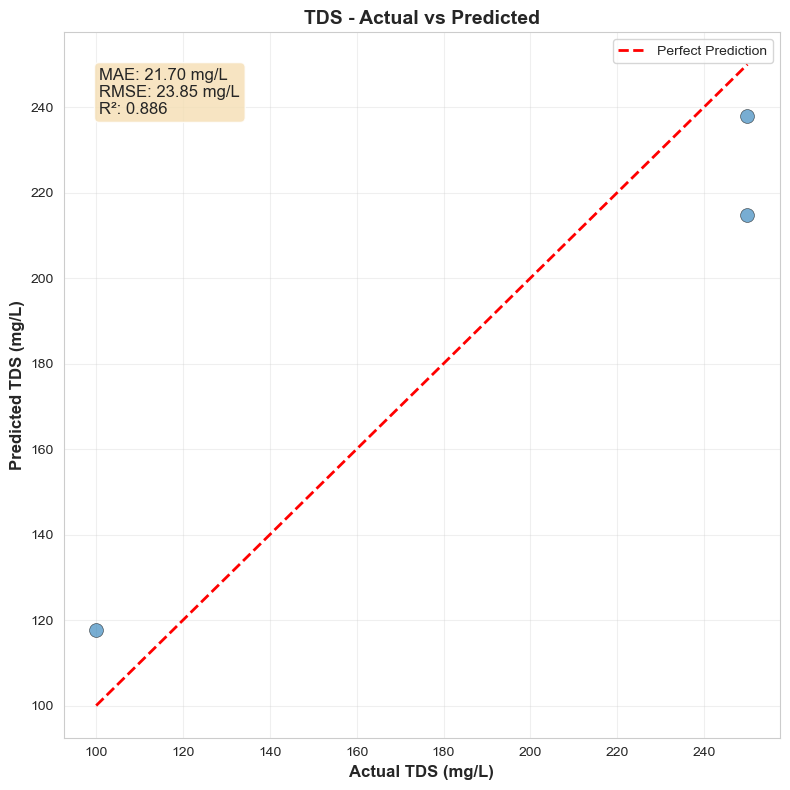

In [34]:
# Graph 1: TDS - Actual vs Predicted
plot_actual_vs_predicted(
    y_test=y_tds_test,
    y_pred=y_tds_pred,
    title='TDS',
    unit='mg/L',
    save_name='tds_actual_vs_predicted.png'
)

Saved: turbidity_actual_vs_predicted.png


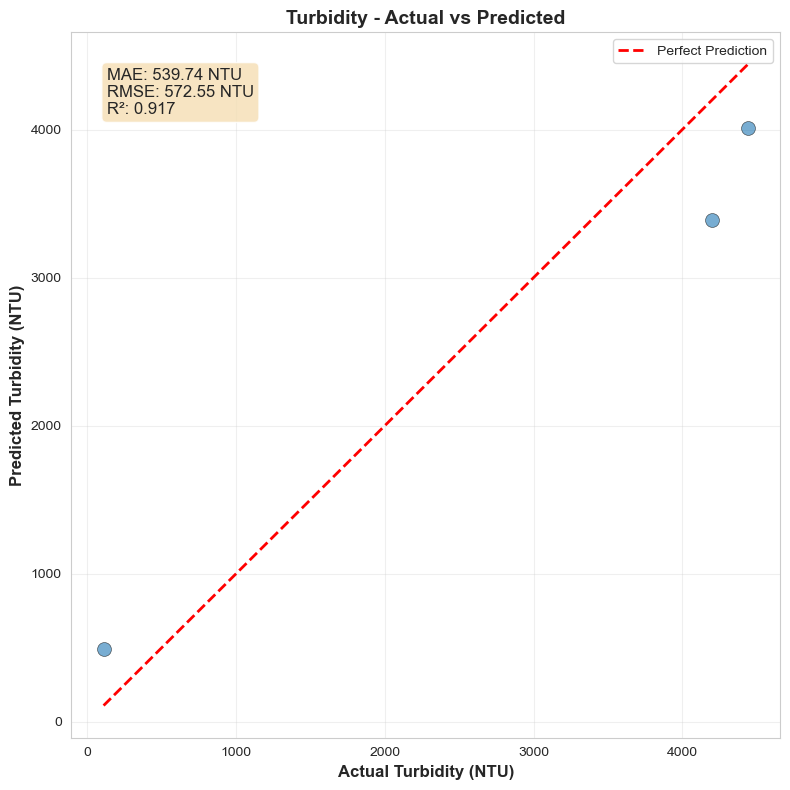

In [35]:
# Graph 2: Turbidity - Actual vs Predicted
plot_actual_vs_predicted(
    y_test=y_turb_test,
    y_pred=y_turb_pred,
    title='Turbidity',
    unit='NTU',
    save_name='turbidity_actual_vs_predicted.png'
)

Saved: tds_feature_importance.png


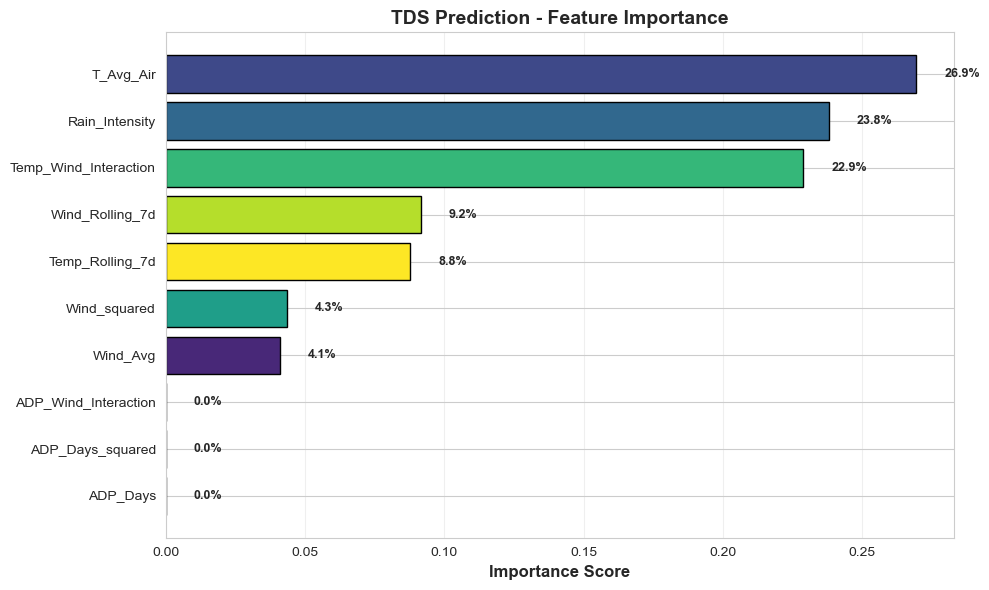

In [36]:
# Graph 3: TDS Feature Importance
plot_feature_importance(
    model=rf_tds,
    feature_names=feature_cols,
    title='TDS Prediction',
    save_name='tds_feature_importance.png'
)

Saved: turbidity_feature_importance.png


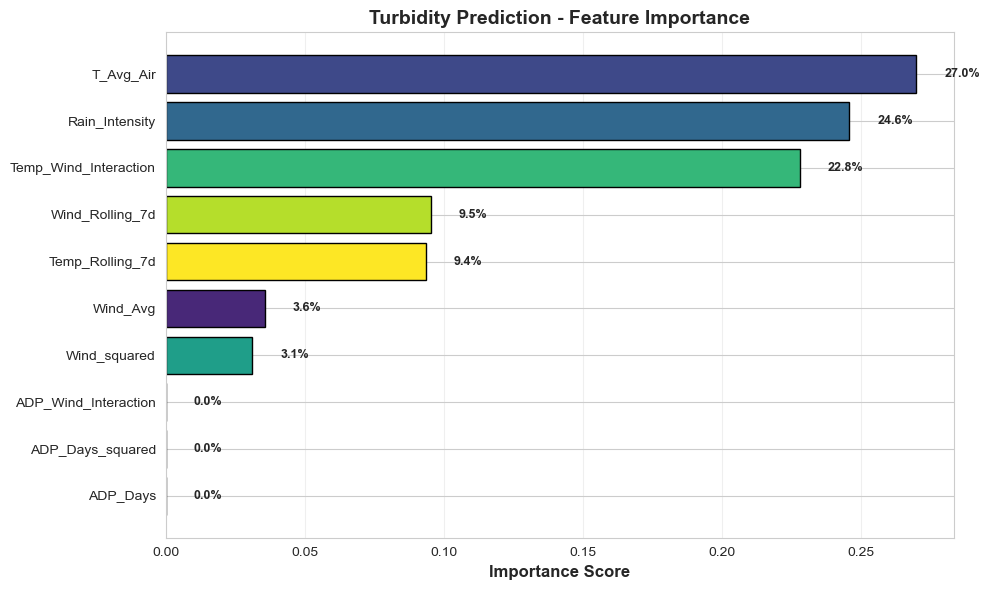

In [37]:
# Graph 4: Turbidity Feature Importance
plot_feature_importance(
    model=rf_turb,
    feature_names=feature_cols,
    title='Turbidity Prediction',
    save_name='turbidity_feature_importance.png'
)

Saved: before_after_filtration.png


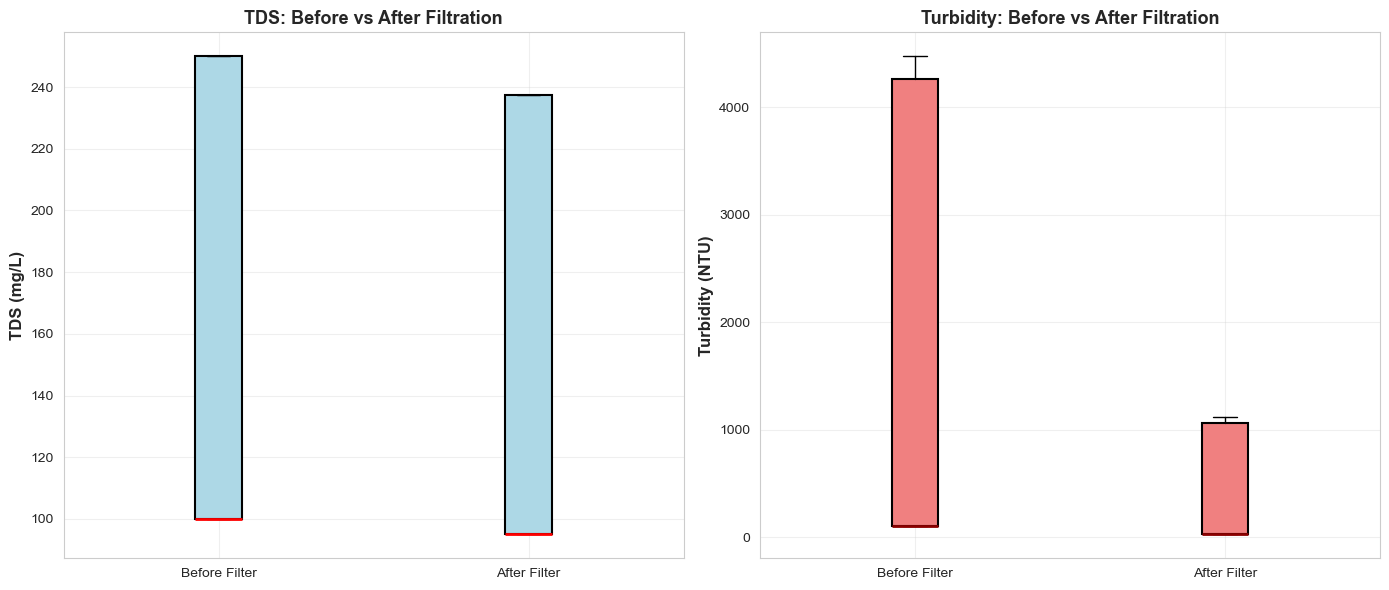

In [38]:
# Graph 5: Before/After Filtration Comparison
plot_before_after_comparison(
    data=data_clean,
    save_name='before_after_filtration.png'
)

# 8. DATA EXPORT

In [39]:
export_cols = [
    'Date', 'ADP_Days', 'Wind_Avg', 'T_Avg_Air', 'Rain_Intensity',
    'TDS_Before', 'Turbidity_Before',
    'TDS_After', 'Turbidity_After',
    'Water_Quality_Class'
]

# Full dataset
df_export = data_clean[export_cols]
df_export.to_csv('smart_rainwater_system_full.csv', index=False)

# Precipitation only (for training)
df_precip = df_export[df_export['Rain_Intensity'] > 0]
df_precip.to_csv('smart_rainwater_system_training.csv', index=False)

# 9. SAVE TRAINED MODELS

In [41]:
os.makedirs('models', exist_ok=True)

In [42]:
# Save TDS model
joblib.dump(rf_tds, 'models/tds_model.pkl')
print(f"\nSaved: models/tds_model.pkl")


Saved: models/tds_model.pkl


In [43]:
# Save Turbidity model
joblib.dump(rf_turb, 'models/turbidity_model.pkl')
print(f"Saved: models/turbidity_model.pkl")

Saved: models/turbidity_model.pkl


In [44]:
# Check file sizes
tds_size = os.path.getsize('models/tds_model.pkl') / (1024 * 1024)
turb_size = os.path.getsize('models/turbidity_model.pkl') / (1024 * 1024)

In [46]:
print(f"\nModel File Sizes:")
print(f"   TDS model:       {tds_size:.2f} MB")
print(f"   Turbidity model: {turb_size:.2f} MB")


Model File Sizes:
   TDS model:       0.12 MB
   Turbidity model: 0.15 MB
